# NY-311 | Desbalanceo de clases + Baseline Logístico

**Pregunta de negocio:**  
Dada una queja que acaba de entrar, ¿qué tan probable es que **no** se resuelva dentro del tiempo esperado?  
¿En qué zonas se concentra ese riesgo?

| target | Significado |
|--------|-------------|
| `0` | Cumple SLA — resuelto dentro del plazo |
| `1` | En riesgo — supera el plazo → genera multa |


## 0. Imports y configuración

In [53]:
import warnings
warnings.filterwarnings("ignore")

import boto3, io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model    import LogisticRegression
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.metrics         import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, f1_score, accuracy_score,
    precision_score, recall_score,
)
from sklearn.dummy           import DummyClassifier

sns.set_theme(style="whitegrid", palette="muted")
print("Librerías OK ✓")


Librerías OK ✓


In [54]:
# ── Rutas S3
BUCKET      = "proyecto-ny311"
PREFIX_GOLD = "gold/ny311"
SPLITS      = ["train", "val", "test"]

# ── Features numéricas ya listas en el Gold
FEATURE_COLS = [
    "latitude", "longitude",
    "sla_days", "penalty_amount_usd",
    "hora_sen", "hora_cos",
    "dia_semana_sen", "dia_semana_cos",
    "mes_sen", "mes_cos",
    "es_fin_de_semana", "trimestre",
    "quejas_por_dia",
    "avg_dias_complaint_type", "std_dias_complaint_type",
    "p75_dias_complaint_type",
    "avg_dias_agency", "avg_dias_borough", "avg_dias_zip",
    "dist_km_agencia", "densidad_zip_30d",
    "Complaint Type_te", "Incident Zip_te",
    "agency_complaint_te", "turno_complaint_te",
    "borough_complaint_te", "borough_canal_te",
]

TARGET = "target"


## 1. Carga de datos desde S3

In [55]:
def leer_parquet_s3(bucket: str, prefix: str) -> pd.DataFrame:
    s3  = boto3.client("s3")
    pag = s3.get_paginator("list_objects_v2")
    frames = []
    for page in pag.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith(".parquet"):
                buf = io.BytesIO()
                s3.download_fileobj(bucket, key, buf)
                buf.seek(0)
                frames.append(pd.read_parquet(buf))
    if not frames:
        raise FileNotFoundError(f"No parquets en s3://{bucket}/{prefix}")
    return pd.concat(frames, ignore_index=True)

dfs = {}
for split in SPLITS:
    dfs[split] = leer_parquet_s3(BUCKET, f"{PREFIX_GOLD}/{split}/")
    print(f"  {split:5}: {len(dfs[split]):>9,} filas  |  {dfs[split].shape[1]} cols")

train_df, val_df, test_df = dfs["train"], dfs["val"], dfs["test"]

# Agregar tasa_riesgo_zip / tasa_cumplimiento_zip si existe
for col in ["tasa_riesgo_zip", "tasa_cumplimiento_zip"]:
    if col in train_df.columns and col not in FEATURE_COLS:
        FEATURE_COLS.append(col)
        print(f"  Columna '{col}' añadida a features.")
        break


  train:   127,428 filas  |  50 cols
  val  :    27,467 filas  |  50 cols
  test :    18,879 filas  |  50 cols
  Columna 'tasa_riesgo_zip' añadida a features.


## 2. Análisis de desbalanceo de clases

In [56]:
vc    = train_df[TARGET].value_counts().sort_index()
total = len(train_df)

for cls, cnt in vc.items():
    label = "CUMPLE SLA ✓" if cls == 0 else "EN RIESGO  ✗"
    print(f"  target={int(cls)} ({label}): {cnt:>9,}  ({100*cnt/total:.2f}%)")

ratio = vc.get(1, 0) / vc.get(0, 1)
print(f"  Ratio minoritaria/mayoritaria: {ratio:.4f}")
if ratio < 0.2:
    print("  ⚠️  Desbalanceo severo → considerar SMOTE o class_weight")

  target=0 (CUMPLE SLA ✓):    98,597  (77.37%)
  target=1 (EN RIESGO  ✗):    28,831  (22.63%)
  Ratio minoritaria/mayoritaria: 0.2924


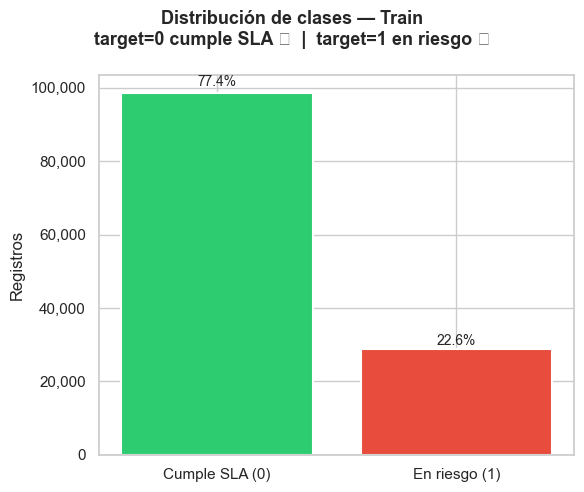

In [57]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle(
    "Distribución de clases — Train\ntarget=0 cumple SLA ✓  |  target=1 en riesgo ✗",
    fontsize=13, fontweight="bold"
)
colores   = ["#2ecc71", "#e74c3c"]
etiquetas = ["Cumple SLA (0)", "En riesgo (1)"]

vc   = train_df[TARGET].value_counts().sort_index()
bars = ax.bar(etiquetas, vc.values, color=colores, edgecolor="white", linewidth=1.5)
ax.set_ylabel("Registros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{100*val/len(train_df):.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("desbalanceo_clases.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Preparación de features

In [58]:
# Sólo columnas numéricas que existan en el df
feat_disponibles = [c for c in FEATURE_COLS if c in train_df.columns]
print(f"Features usadas: {len(feat_disponibles)}")

X_train = train_df[feat_disponibles].select_dtypes(include="number")
y_train = train_df[TARGET]

X_val   = val_df[feat_disponibles].select_dtypes(include="number")
y_val   = val_df[TARGET]

X_test  = test_df[feat_disponibles].select_dtypes(include="number")
y_test  = test_df[TARGET]

print(f"X_train shape: {X_train.shape}")
print(f"X_val   shape: {X_val.shape}")
print(f"X_test  shape: {X_test.shape}")


Features usadas: 28
X_train shape: (127428, 28)
X_val   shape: (27467, 28)
X_test  shape: (18879, 28)


## 4. Baseline ingenuo — DummyClassifier

Predice **siempre la clase mayoritaria**.  
Es el piso mínimo: si el modelo real no le gana, algo está mal.


In [59]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

print("Classification report (Val) — DummyClassifier:\n")
print(classification_report(y_val, y_pred_dummy,
      target_names=["Cumple SLA (0)", "En riesgo (1)"]))


Classification report (Val) — DummyClassifier:

                precision    recall  f1-score   support

Cumple SLA (0)       0.85      1.00      0.92     23332
 En riesgo (1)       0.00      0.00      0.00      4135

      accuracy                           0.85     27467
     macro avg       0.42      0.50      0.46     27467
  weighted avg       0.72      0.85      0.78     27467



## 5. Baseline Logístico — Regresión Logística




In [60]:
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    )),
])

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_val)
y_prob_lr = pipe_lr.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_prob_lr)

print(f"ROC-AUC (Val): {roc_auc:.4f}\n")
print("Classification report (Val) — Regresión Logística:\n")
print(classification_report(y_val, y_pred_lr,
      target_names=["Cumple SLA (0)", "En riesgo (1)"]))


ROC-AUC (Val): 0.8315

Classification report (Val) — Regresión Logística:

                precision    recall  f1-score   support

Cumple SLA (0)       0.94      0.78      0.85     23332
 En riesgo (1)       0.36      0.70      0.47      4135

      accuracy                           0.77     27467
     macro avg       0.65      0.74      0.66     27467
  weighted avg       0.85      0.77      0.79     27467



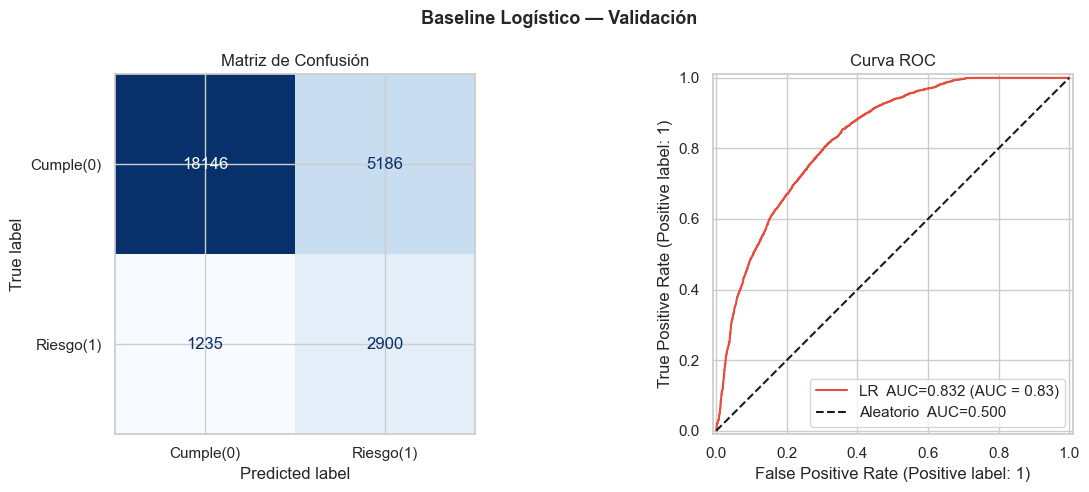

In [61]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Baseline Logístico — Validación", fontsize=13, fontweight="bold")

cm = confusion_matrix(y_val, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=["Cumple(0)", "Riesgo(1)"]).plot(
    ax=ax1, colorbar=False, cmap="Blues"
)
ax1.set_title("Matriz de Confusión")

RocCurveDisplay.from_predictions(y_val, y_prob_lr, ax=ax2, color="#e74c3c",
                                  name=f"LR  AUC={roc_auc:.3f}")
ax2.plot([0, 1], [0, 1], "k--", label="Aleatorio  AUC=0.500")
ax2.legend()
ax2.set_title("Curva ROC")

plt.tight_layout()
plt.savefig("baseline_logistico.png", dpi=150, bbox_inches="tight")
plt.show()


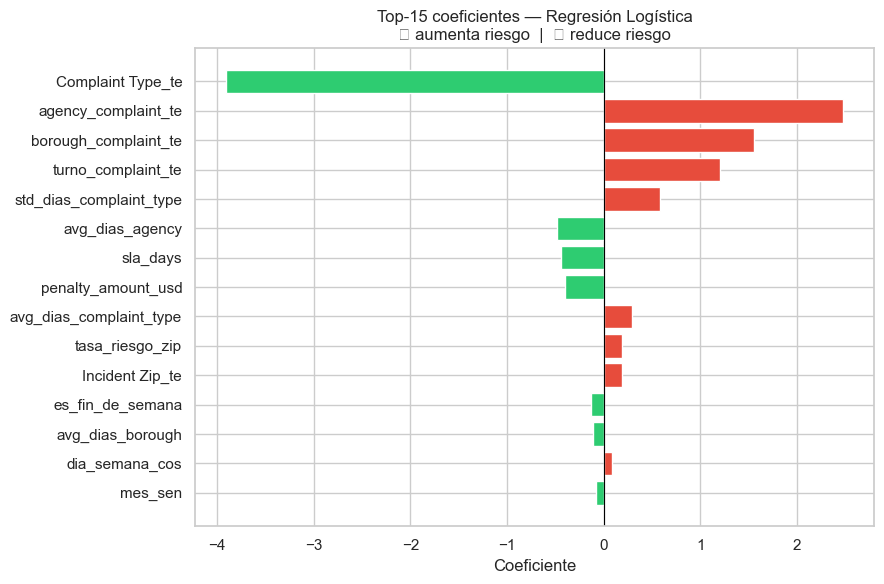

In [62]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef":    pipe_lr.named_steps["model"].coef_[0],
}).assign(abs_coef=lambda d: d["coef"].abs()) \
  .sort_values("abs_coef", ascending=False) \
  .head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colores_coef = ["#e74c3c" if c > 0 else "#2ecc71" for c in coef_df["coef"]]
ax.barh(coef_df["feature"][::-1], coef_df["coef"][::-1], color=colores_coef[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top-15 coeficientes — Regresión Logística\n"
             "🔴 aumenta riesgo  |  🟢 reduce riesgo", fontsize=12)
ax.set_xlabel("Coeficiente")
plt.tight_layout()
plt.savefig("coeficientes_lr.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Análisis geográfico del riesgo

In [63]:
# Probabilidad de riesgo sobre train (pipe_lr ya incluye imputer+scaler)
train_df = train_df.copy()
train_df["prob_riesgo"] = pipe_lr.predict_proba(X_train)[:, 1]

# Riesgo real (target) por Borough
borough_risk = (
    train_df.groupby("Borough")
    .agg(tasa_riesgo=("target", "mean"), quejas=("target", "count"))
    .sort_values("tasa_riesgo", ascending=False)
    .reset_index()
)
print("Tasa de riesgo por Borough:")
print(borough_risk.to_string(index=False))


Tasa de riesgo por Borough:
      Borough  tasa_riesgo  quejas
STATEN ISLAND     0.275705    5495
       QUEENS     0.242865   31009
        BRONX     0.239749   23437
    MANHATTAN     0.210724   28962
     BROOKLYN     0.209326   38514
  UNSPECIFIED     0.090909      11


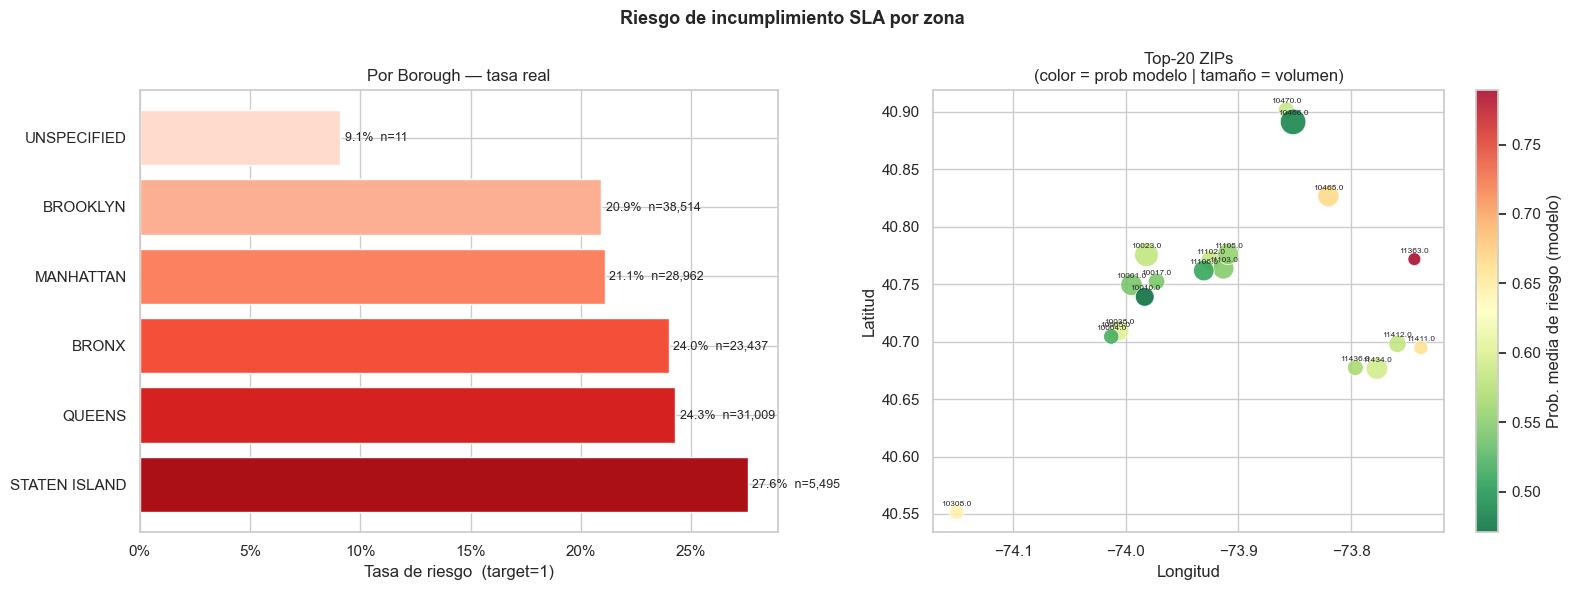

In [64]:
# Top-20 ZIPs con mayor riesgo real (mínimo 100 quejas)
zip_risk = (
    train_df.groupby("Incident Zip")
    .agg(
        tasa_riesgo=("target",      "mean"),
        prob_media=("prob_riesgo",  "mean"),   # probabilidad predicha media
        quejas=("target",           "count"),
        lat=("latitude",            "mean"),
        lon=("longitude",           "mean"),
    )
    .query("quejas >= 100")
    .sort_values("tasa_riesgo", ascending=False)
    .head(20)
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Riesgo de incumplimiento SLA por zona", fontsize=13, fontweight="bold")

# Borough — tasa real
ax1.barh(borough_risk["Borough"], borough_risk["tasa_riesgo"],
         color=sns.color_palette("Reds_r", len(borough_risk)))
ax1.set_xlabel("Tasa de riesgo  (target=1)")
ax1.set_title("Por Borough — tasa real")
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
for i, row in borough_risk.iterrows():
    ax1.text(row["tasa_riesgo"] + 0.002, i,
             f"{100*row['tasa_riesgo']:.1f}%  n={row['quejas']:,}",
             va="center", fontsize=9)

# Scatter geográfico — color = prob_media predicha, tamaño = volumen
sc = ax2.scatter(
    zip_risk["lon"], zip_risk["lat"],
    c=zip_risk["prob_media"], cmap="RdYlGn_r",
    s=zip_risk["quejas"] / zip_risk["quejas"].max() * 300 + 40,
    alpha=0.85, edgecolors="white", linewidths=0.6,
)
plt.colorbar(sc, ax=ax2, label="Prob. media de riesgo (modelo)")
ax2.set_title("Top-20 ZIPs\n(color = prob modelo | tamaño = volumen)")
ax2.set_xlabel("Longitud")
ax2.set_ylabel("Latitud")
for _, row in zip_risk.iterrows():
    ax2.annotate(row["Incident Zip"], (row["lon"], row["lat"]),
                 fontsize=6, ha="center", va="bottom",
                 xytext=(0, 4), textcoords="offset points")

plt.tight_layout()
plt.savefig("riesgo_geografico.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Resumen comparativo de baselines

In [65]:
# Dummy con strategy="prior" para obtener probabilidades y calcular ROC-AUC = 0.5
dummy_prior = DummyClassifier(strategy="prior", random_state=42)
dummy_prior.fit(X_train, y_train)
y_prob_dummy = dummy_prior.predict_proba(X_val)[:, 1]

resultados = []
for nombre, y_pred, y_prob in [
    ("DummyClassifier (mayoría)", y_pred_dummy, y_prob_dummy),
    ("Regresión Logística",       y_pred_lr,    y_prob_lr),
]:
    resultados.append({
        "Modelo":      nombre,
        "Accuracy":    round(accuracy_score(y_val,  y_pred), 4),
        "Precision":   round(precision_score(y_val, y_pred, pos_label=1, zero_division=0), 4),
        "Recall":      round(recall_score(y_val,    y_pred, pos_label=1, zero_division=0), 4),
        "F1 (riesgo)": round(f1_score(y_val,        y_pred, pos_label=1, zero_division=0), 4),
        "ROC-AUC":     round(roc_auc_score(y_val,   y_prob), 4),
    })

pd.DataFrame(resultados).set_index("Modelo")


,Accuracy,Precision,Recall,F1 (riesgo),ROC-AUC
Modelo,,,,,
DummyClassifier (mayoría),0.8495,0.0000,0.0000,0.0000,0.5000
Regresión Logística,0.7662,0.3586,0.7013,0.4746,0.8315
